In [2]:
import torch
from torch.utils.data import DataLoader

from coronary_analysis.models.segmentation import CoronaryUNetPP
from coronary_analysis.datasets import DCA1FSCADDataset
from coronary_analysis.transforms import get_val_transforms
from coronary_analysis.utils import show_image

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [4]:
model = CoronaryUNetPP(encoder_name="resnet34").to(device)
model.load_state_dict(
    torch.load(
        "../models/best_coronary_unet.pth", weights_only=True, map_location=device
    )
)
model.eval()

CoronaryUNetPP(
  (model): UnetPlusPlus(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         

In [ ]:
BATCH_SIZE = 1
IMG_SIZE = 256
IMAGE_DIR_DCA1 = "raw_datasets/DCA1/Database_134_Angiograms"
IMAGE_DIR_FS_CAD = "raw_datasets/FS-CAD/FS-CAD"

test_ds = DCA1FSCADDataset(
    dca1_image_dir=f"{IMAGE_DIR_DCA1}/test",
    fs_cad_image_dir=f"{IMAGE_DIR_FS_CAD}/test",
    transform=get_val_transforms(IMG_SIZE),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

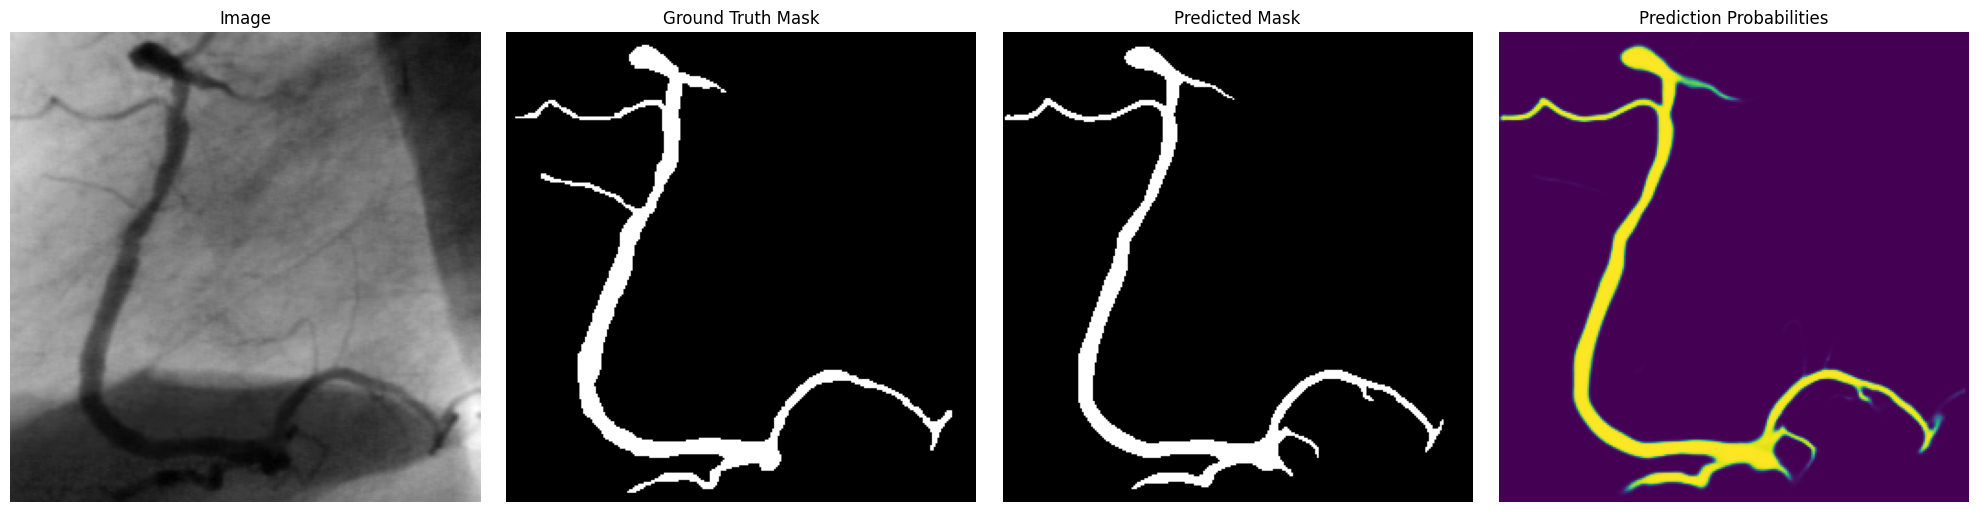

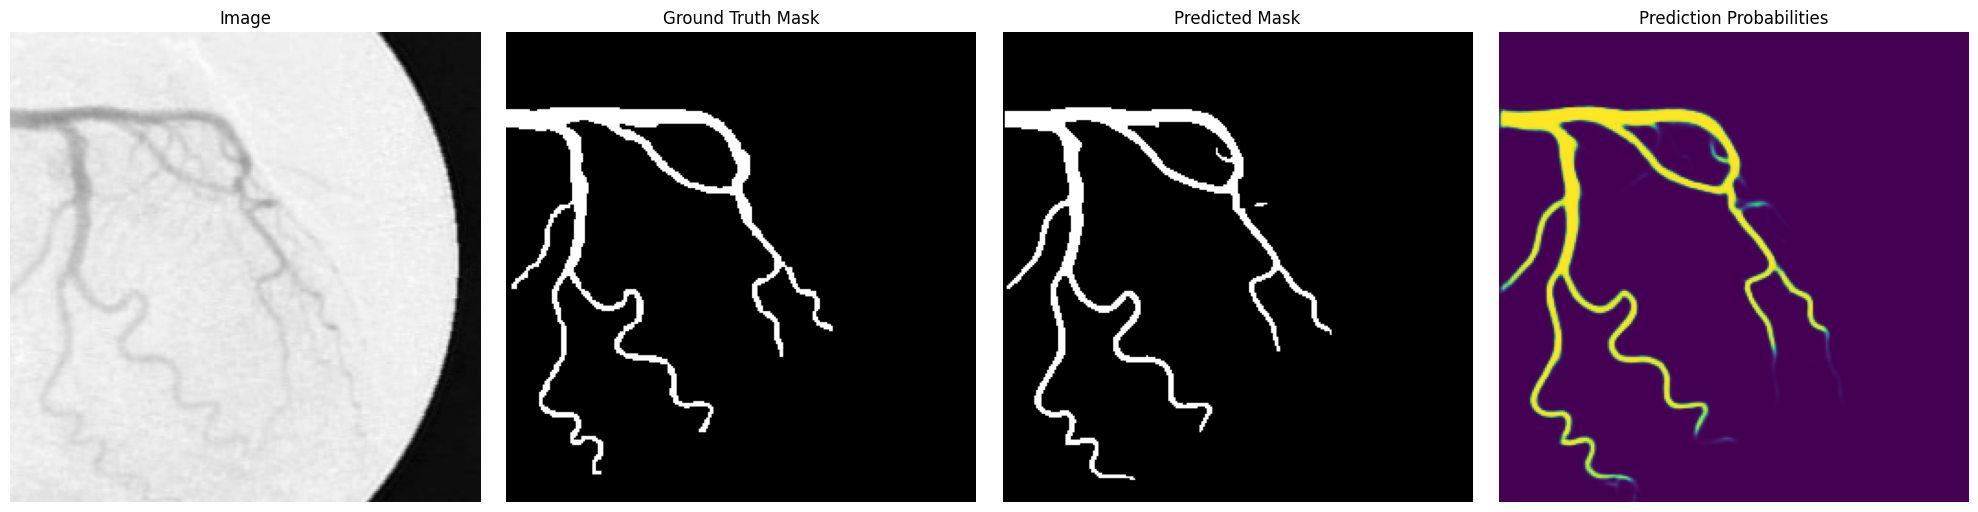

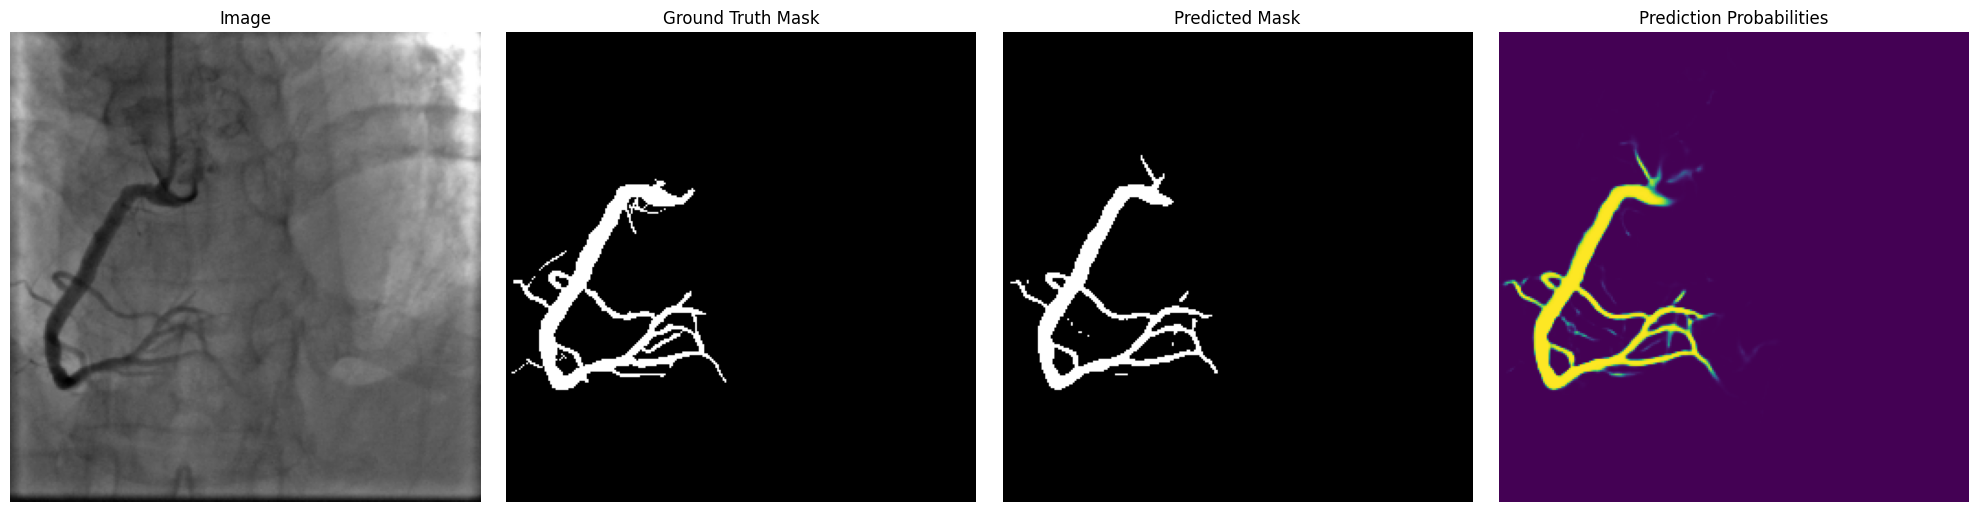

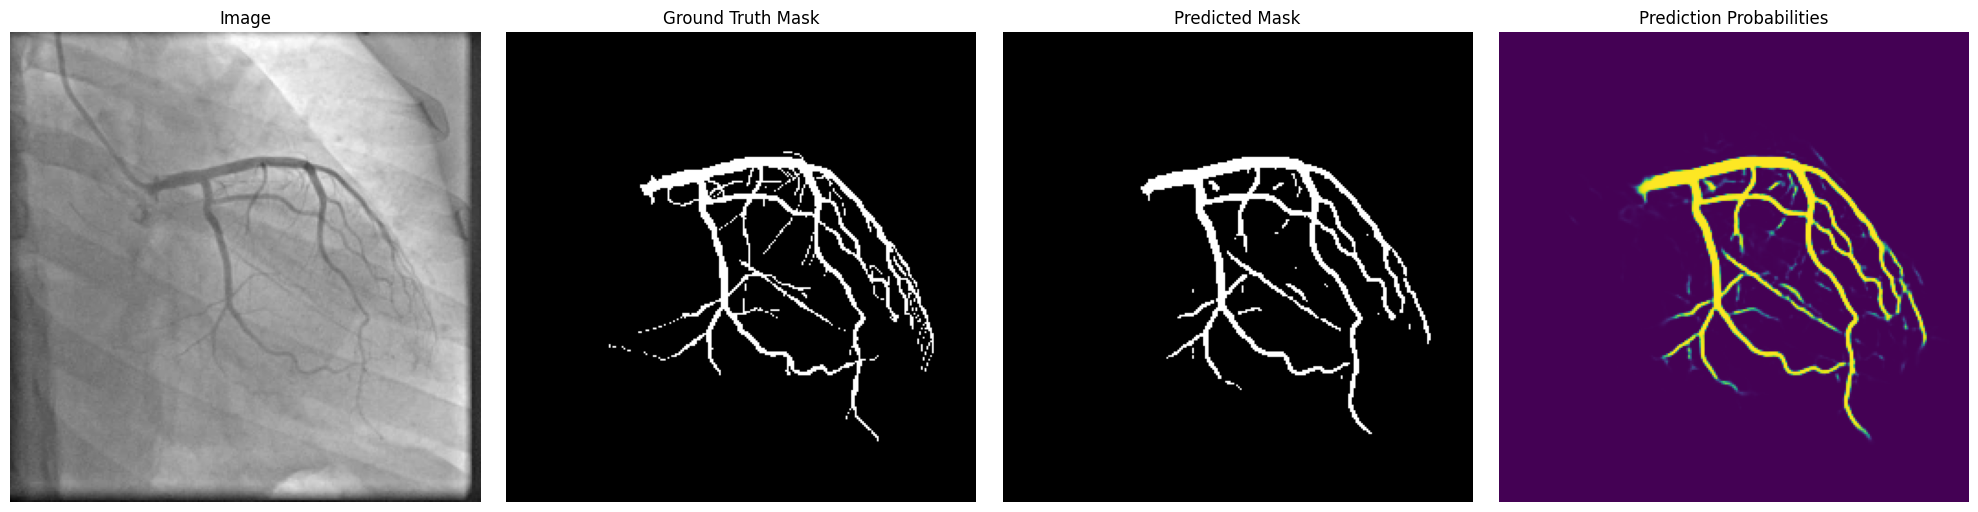

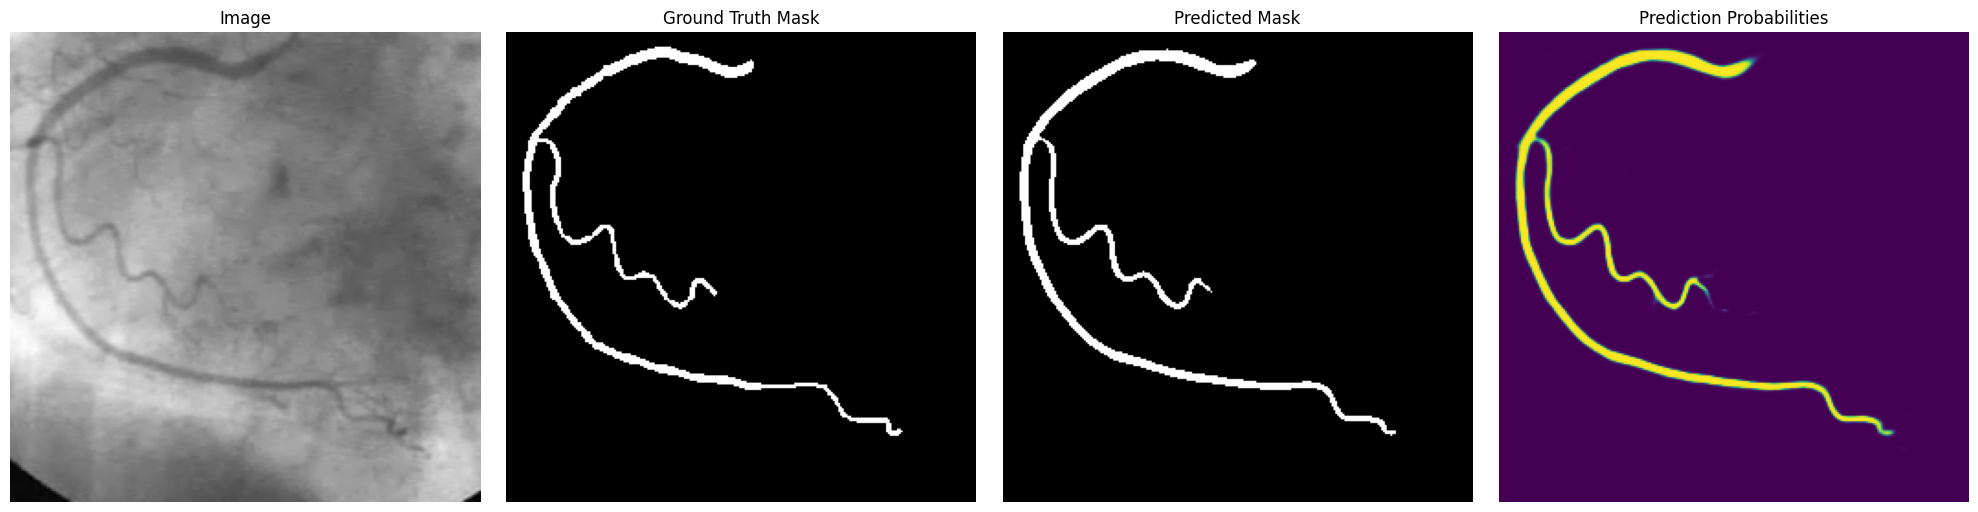

In [8]:
with torch.no_grad():
    test_loader_iter = iter(test_loader)
    for i in range(5):
        images, masks = next(test_loader_iter)
        images = images.to(device)
        masks = masks.to(device)

        probs = model.predict_proba(images)
        preds = (probs > 0.5).float()

        show_image(
            images[0, 0].cpu().numpy(),
            masks[0, 0].cpu().numpy(),
            preds[0, 0].cpu().numpy(),
            probs[0, 0].cpu().numpy(),
            titles=[
                "Image",
                "Ground Truth Mask",
                "Predicted Mask",
                "Prediction Probabilities",
            ],
            cmap=["gray", "gray", "gray", None],
        )